# **DATA SCIENCE PROJECT ON RICE LEAF DISEASE DETECTION**
# INTRODUCTION

The rice leaf suffers from several bacterial, viral, or fungal diseases and these diseases reduce rice production significantly. To sustain rice demand for a vast population globally.The rice leaves related diseases often pose threats to the sustainable production of rice affecting many farmers around the world. Early diagnosis and appropriate remedy of the rice leaf infection is crucial in facilitating healthy growth of the rice plants to ensure adequate supply and food security to the rapidly increasing population.


# RICE LEAF DISEASE:
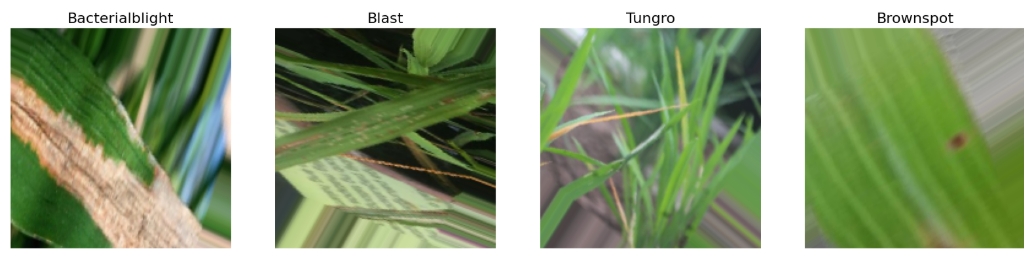

# PYTHON IMPLIMENTATION

# Import libraries

In [3]:
import numpy as np
import keras
from tensorflow import keras
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.preprocessing.image import img_to_array
import matplotlib.pyplot as plt
%matplotlib inline
import random
import cv2
import os
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Connect to google drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

folder_path = '/content/drive/MyDrive/rice leaf/Rice Leaf Disease Images'
print(os.listdir(folder_path))

['Bacterialblight', 'Brownspot', 'Tungro', 'Blast']


# Install split-folders if not already installed

In [3]:
!pip install split-folders

import splitfolders

# Update the path to your raw image data in Google Drive
# Based on your previous steps, this is the correct path for your raw images.
raw_data_path = '/content/drive/MyDrive/rice leaf/Rice Leaf Disease Images'
output_base_dir = '/content/drive/MyDrive/rice leaf/output'

# Ensure the output directory exists
import os
os.makedirs(output_base_dir, exist_ok=True)

print(f"Splitting data from: {raw_data_path}")
print(f"Outputting to: {output_base_dir}")

splitfolders.ratio(raw_data_path, output=output_base_dir, seed=1337, ratio=(.8, 0.1, 0.1), group_prefix=None)

print("Data splitting complete. You can now define your data generators with the generated train/val/test directories.")

Splitting data from: /content/drive/MyDrive/rice leaf/Rice Leaf Disease Images
Outputting to: /content/drive/MyDrive/rice leaf/output


Copying files: 5932 files [29:51,  3.31 files/s]

Data splitting complete. You can now define your data generators with the generated train/val/test directories.


In [4]:
# Sorting the path of data into variable
# These paths should point to the output of the splitfolders operation
train_dir = '/content/drive/MyDrive/rice leaf/output/train'  # Location of training images
validation_dir = '/content/drive/MyDrive/rice leaf/output/val' # Location of validation images
test_dir ='/content/drive/MyDrive/rice leaf/output/test' # Location of test images

print(f"Train directory: {train_dir}")
print(f"Validation directory: {validation_dir}")
print(f"Test directory: {test_dir}")

Train directory: /content/drive/MyDrive/rice leaf/output/train
Validation directory: /content/drive/MyDrive/rice leaf/output/val
Test directory: /content/drive/MyDrive/rice leaf/output/test


# GENERATING TRAINING AND VALIDATION BATCHES OF IMAGES

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Generating batches of image data
train_datagen = ImageDataGenerator(
    rescale= (1./255),
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

val_datagen = ImageDataGenerator(rescale=(1./255))


train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(180,180),
    batch_size=16,
    color_mode='rgb',
    class_mode='categorical')


val_generator = val_datagen.flow_from_directory(
    validation_dir,
    target_size=(180,180),
    batch_size=16,
    color_mode='rgb',
    class_mode='categorical')

Found 4850 images belonging to 4 classes.
Found 692 images belonging to 4 classes.


## Plotting train images with their labels

In [7]:
# plotting train images with their labels
def plots(ims, figsize=(20,25), rows=4, interp = False, title = None):
    f = plt.figure(figsize=figsize)
    cols = len(ims) // rows if len(ims) % 2 ==0 else len(ims) // rows+1
    for i in range(len(ims)):
        sp = f.add_subplot(rows, cols, i+1)
        sp.axis('off')
        sp.set_title(class_names[title[i].tolist().index(1)],fontsize=16)
        plt.imshow(ims[i])


# Make list of classes, ensuring it matches the 4 classes found by ImageDataGenerator in alphabetical order
# Based on os.listdir output: ['Bacterialblight', 'Brownspot', 'Tungro', 'Blast']
# ImageDataGenerator will sort them alphabetically: 'Bacterialblight', 'Blast', 'Brownspot', 'Tungro'
class_names = ['Bacterialblight', 'Blast', 'Brownspot', 'Tungro']

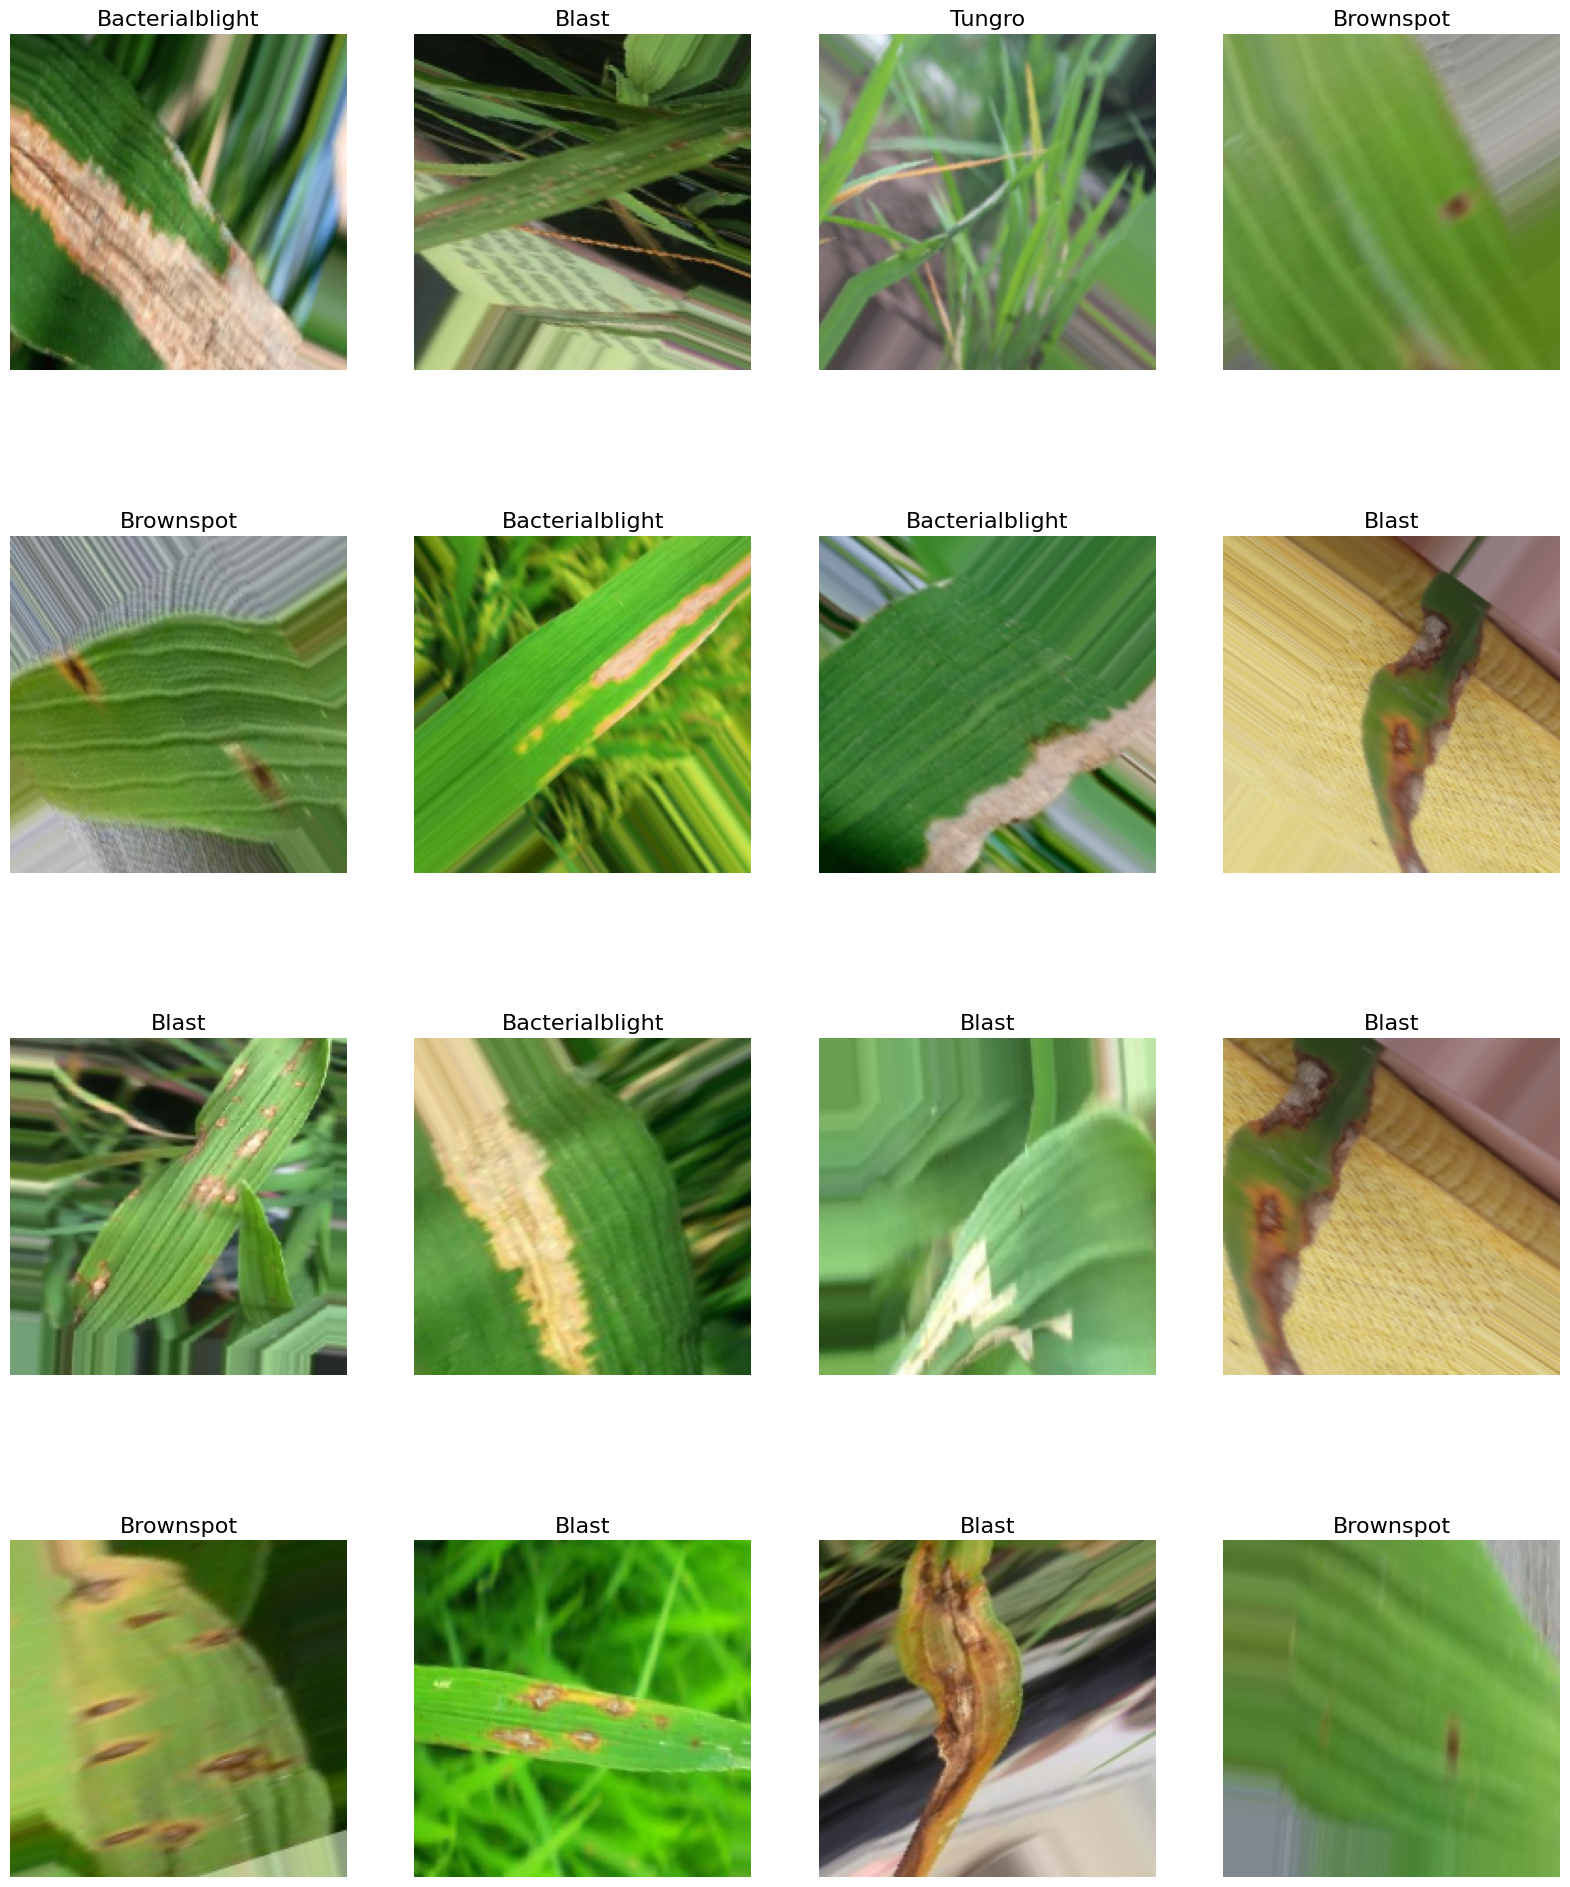

In [9]:
import matplotlib.pyplot as plt

imgs, labels = next(train_generator)
plots(imgs, title = labels)

# CNN MODEL ARCHITECTURE

In [10]:
from keras import models, layers
model = models.Sequential()
model.add(layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu',input_shape=(180,180,3)))
model.add(layers.MaxPool2D(pool_size=(2,2)))
model.add(layers.Conv2D(filters=64,kernel_size=(3,3),activation= 'relu'))
model.add(layers.MaxPool2D(pool_size=(2,2)))
model.add(layers.Conv2D(filters=128,kernel_size=(3,3),activation= 'relu'))
model.add(layers.MaxPool2D(pool_size=(2,2)))
model.add(layers.Conv2D(filters=256,kernel_size=(3,3),activation= 'relu'))
model.add(layers.MaxPool2D(pool_size=(2,2)))
model.add(layers.Dropout(rate=0.5))
model.add(layers.Flatten())
model.add(layers.Dense(4, activation ='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# PLOTTING GRAPHICAL REPRESENTATION OF MODEL

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
graphviz is already the newest version (2.42.2-6ubuntu0.1).
0 upgraded, 0 newly installed, 0 to remove and 5 not upgraded.


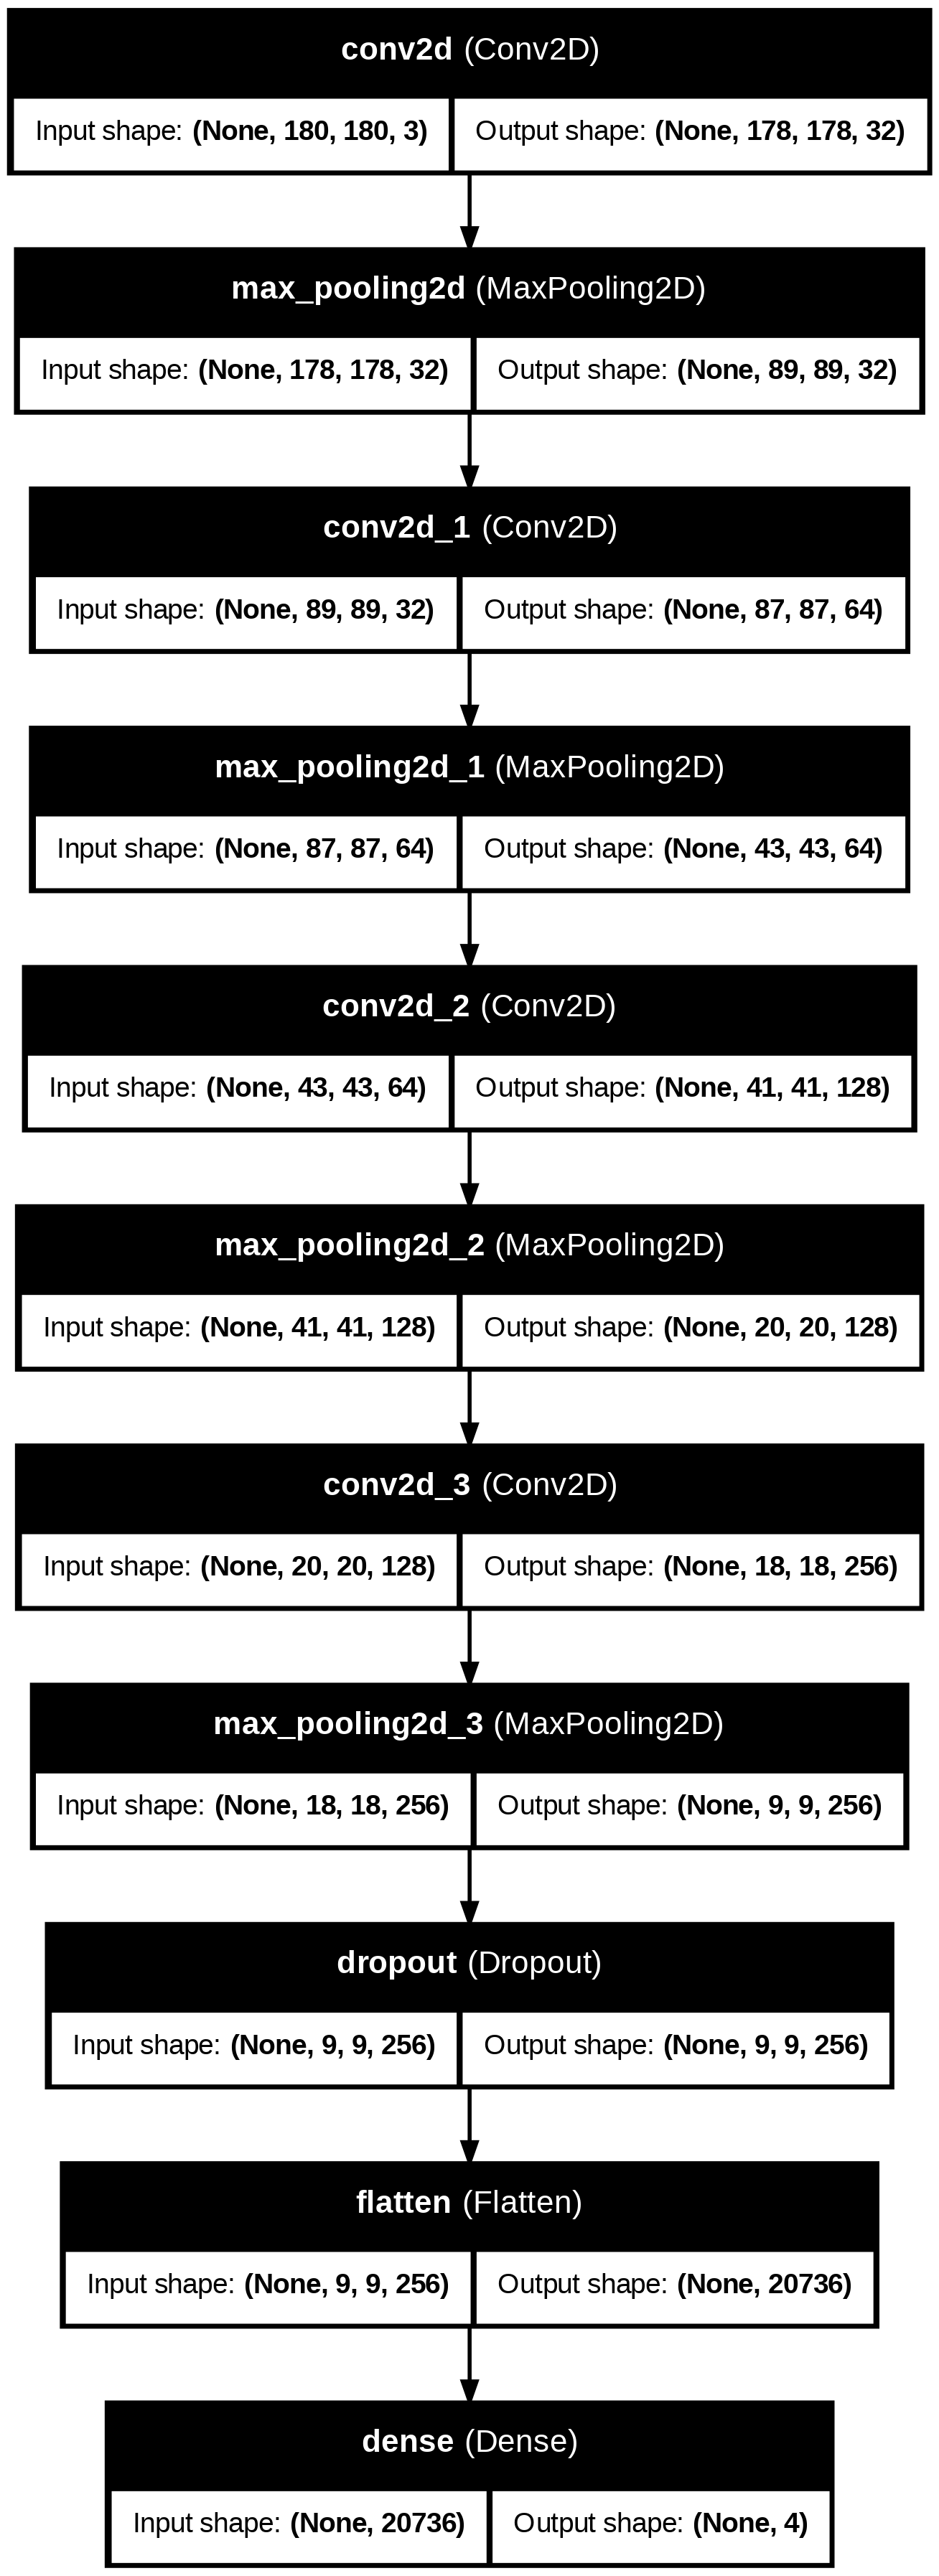

In [11]:
# Install graphviz system package, a dependency for plotting Keras models
!apt install graphviz

import pydotplus
from tensorflow.keras.utils import plot_model

# Plot the model architecture
plot_model(model, show_shapes=True, show_layer_names=True)

# Summary of model

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │        82,948 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 471,364 (1.80 MB)

 Trainable params: 471,364 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

# COMPILE MODEL

In [13]:
from tensorflow.keras import optimizers
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

# Train model

In [14]:
# Fitting the data

history = model.fit(train_generator,
    epochs=20, # epochs used to how many itertion (1fp + loss + 1bp)
    validation_data = val_generator,
)

Epoch 1/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 440s 1s/step - accuracy: 0.5868 - loss: 0.9803 - val_accuracy: 0.7399 - val_loss: 0.7141
Epoch 2/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 405s 1s/step - accuracy: 0.7742 - loss: 0.6000 - val_accuracy: 0.8049 - val_loss: 0.4625
Epoch 3/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 406s 1s/step - accuracy: 0.8245 - loss: 0.4826 - val_accuracy: 0.8786 - val_loss: 0.3015
Epoch 4/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 407s 1s/step - accuracy: 0.8511 - loss: 0.3928 - val_accuracy: 0.9350 - val_loss: 0.1978
Epoch 5/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 406s 1s/step - accuracy: 0.8934 - loss: 0.2776 - val_accuracy: 0.9090 - val_loss: 0.1989
Epoch 6/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 406s 1s/step - accuracy: 0.8973 - loss: 0.2679 - val_accuracy: 0.9624 - val_loss: 0.1454
Epoch 7/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 398s 1s/step - accuracy: 0.9188 - loss: 0.2145 - val_accuracy: 0.9566 - val_loss: 0.1043
Epoch 8/20
304/304 ━━━━━━━━━━━━━━━━━━━━ 403s 1s/step - accuracy: 0.9338 - loss: 0.1790 - val_accu

# AFTER TRAINING

*  Validation accuracy.99.71%
*   Training accuracy.97.77%







# MODEL SAVING

In [15]:
model.save("model.h5")

# PLOTTING THE TRAINING ACCURACY AND VALIDATION ACCURACY AND TRAINING LOSS AND VALIDATION LOSS

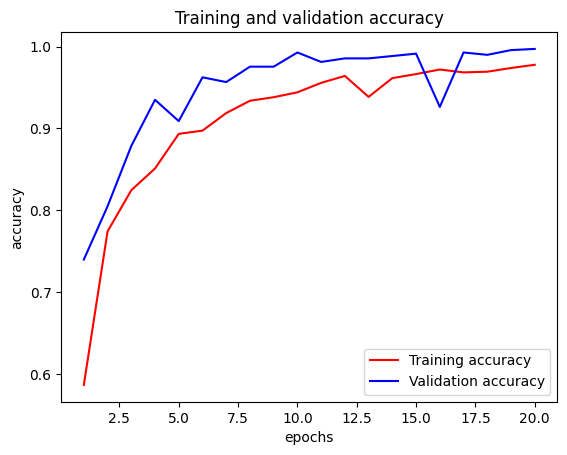

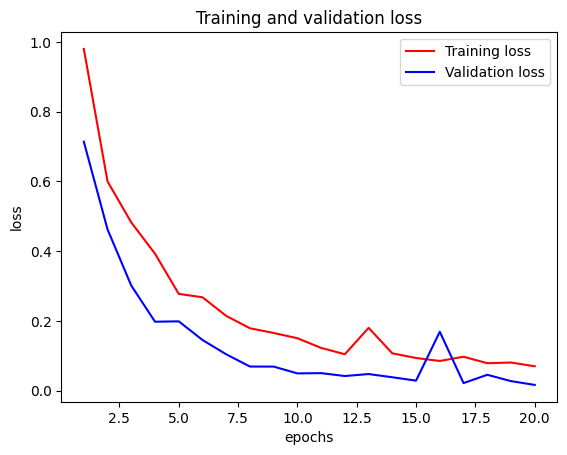

In [16]:
# Step:9 Plotting the training accuracy and validation accuracy
# Plotting the traning loss and validation loss
import matplotlib.pyplot as plt
accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(accuracy) + 1)
plt.plot(epochs, accuracy, "r", label="Training accuracy")
plt.plot(epochs, val_accuracy, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()

# CREATED MODEL SUMMARY

In [18]:
import tensorflow as tf

model = tf.keras.models.load_model("model.h5")
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 20736)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │        82,948 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 471,366 (1.80 MB)

 Trainable params: 471,364 (1.80 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

# EVALUATION AND TESTING MODEL

In [19]:
test_datagen = ImageDataGenerator(rescale=(1./255))


test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(180,180),
    batch_size=16,
    color_mode='rgb',
    class_mode='categorical')

Found 605 images belonging to 4 classes.


In [20]:
model.evaluate(test_generator)

38/38 ━━━━━━━━━━━━━━━━━━━━ 18s 443ms/step - accuracy: 0.9934 - loss: 0.0192


[0.019193844869732857, 0.9933884143829346]


* Here the loss is 0.019 and the accuracy of the model is 0.99 percent means 99%.




# VISUALISE THE PREDICTION OF MODEL

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


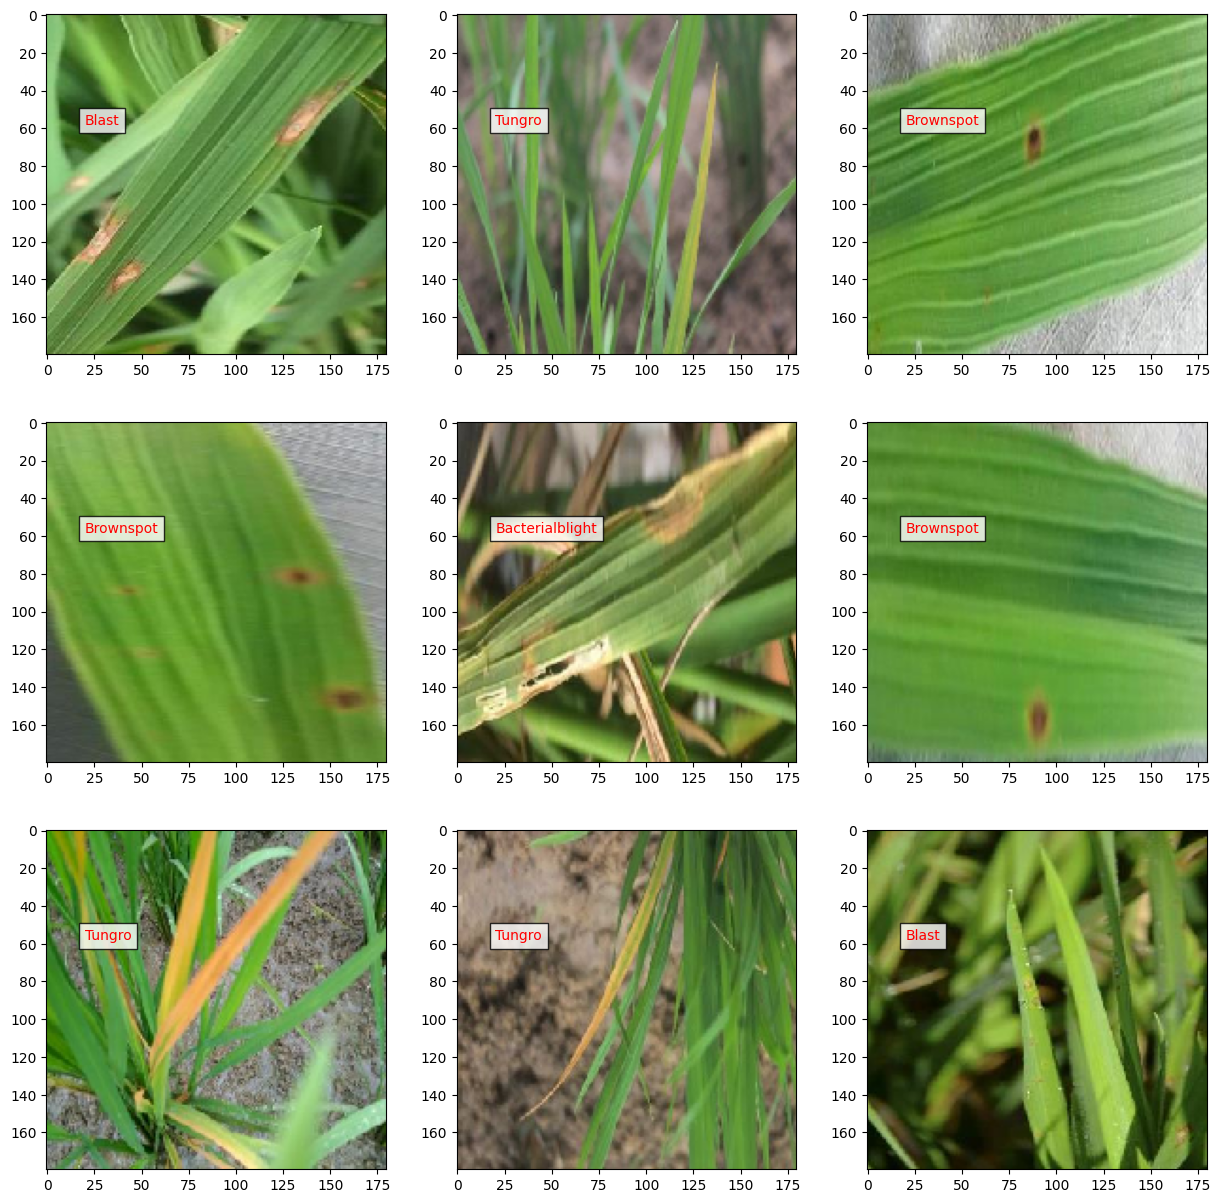

In [22]:
import numpy as np
# Visualise the prediction of the model
imgs, labels = next(test_generator)
fig =plt.figure(figsize=(15,15))
columns = 3
rows = 3
for i in range(columns*rows):
    fig.add_subplot(rows, columns, i+1)
    img_t = np.expand_dims(imgs[i],axis=0)
    prediction = model.predict(img_t)
    idx = prediction[0].tolist().index(max(prediction[0]))
    plt.text(20,58, class_names[idx],color='red',fontsize=10,bbox=dict(facecolor='white',alpha=0.8))
    plt.imshow(imgs[i])